In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 16})

### Set cluster name and position

In [142]:
#cluster_name, cluster_ra, cluster_dec = 'Abell2065', 230.62156, 27.70763
#cluster_name, cluster_ra, cluster_dec = 'Abell2063', 230.77116,  8.60859 
cluster_name, cluster_ra, cluster_dec = 'Abell1795', 207.21886, 26.59160

### Read CSV file containing SDSS data (assumes the file lives in same directory as your notebook, and is named cluster_name_SDSS.csv)

In [143]:
from astropy.io import ascii
SDSS=ascii.read(cluster_name+'_SDSS.csv')
print('{} objects in table'.format(len(SDSS)))
print('Column names: ',SDSS.colnames)

25175 objects in table
Column names:  ['ra', 'dec', 'type', 'u', 'g', 'r', 'i', 'z', 'modelMagErr_u', 'modelMagErr_g', 'modelMagErr_r', 'modelMagErr_i', 'modelMagErr_z', 'lnLDeV_g', 'lnLExp_g', 'redshift', 'redshiftErr']


### Plot a (logarithmic) histogram showing the number of objects as a function of r-band magnitude. Also plot a line at the SDSS limiting r-band magnitude of r=22.2

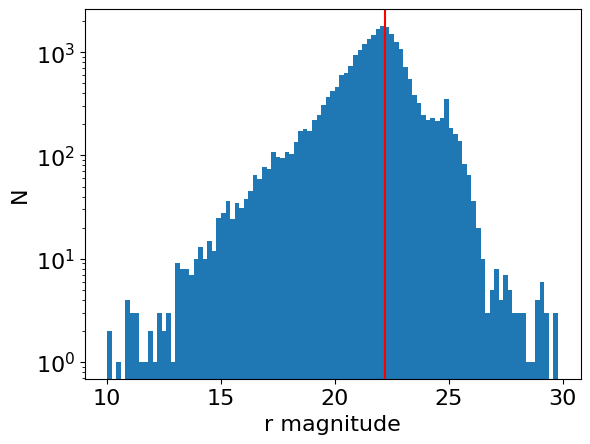

In [144]:
bins=np.arange(10,30,0.2)
plt.hist(SDSS['r'],bins=bins)
plt.yscale('log')
plt.axvline(x=22.2,color='red')
plt.xlabel('r magnitude')
plt.ylabel('N');

### Plot r mag uncertainty versus r mag. If you want your magnitude uncertainty to be 0.1 mag or better, what is the rough magnitude limit of your analysis?

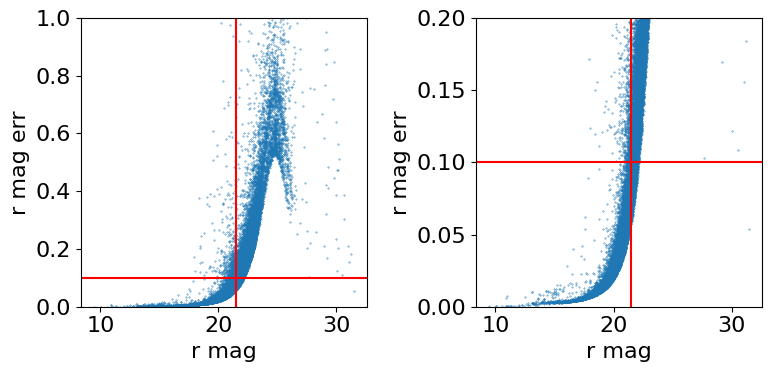

In [145]:
Fig,(FullPlot,ZoomPlot) = plt.subplots(1,2,figsize=(8,4))

for subplot in [FullPlot,ZoomPlot]:
    subplot.scatter(SDSS['r'],SDSS['modelMagErr_r'],s=0.1) ## Note s=0.1 -- there are many points, so make them small!
    subplot.set_xlabel('r mag')
    subplot.set_ylabel('r mag err')
    subplot.axhline(y=0.1,color='red')
    subplot.axvline(x=21.5,color='red')
    
FullPlot.set_ylim(0,1)
ZoomPlot.set_ylim(0,0.2)
Fig.tight_layout()

### Plot dec vs ra (so a sky map) of resolved sources (type=3) brighter than r=20. Make another for unresolved sources (type=6) brighter than r=20. Think about the differences.

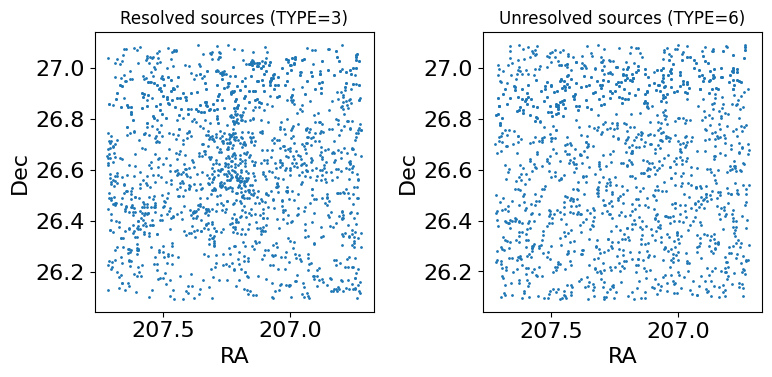

In [146]:
Fig,(ResPlot,UnresPlot) = plt.subplots(1,2,figsize=(8,4))

wantmag=SDSS['r']<20

resolved=np.logical_and(SDSS['type']==3,wantmag)
ResPlot.scatter(SDSS['ra'][resolved],SDSS['dec'][resolved],s=1)
ResPlot.set_title('Resolved sources (TYPE=3)',fontsize=12)

unresolved=np.logical_and(SDSS['type']==6,wantmag)
UnresPlot.scatter(SDSS['ra'][unresolved],SDSS['dec'][unresolved],s=1)
UnresPlot.set_title('Unresolved sources (TYPE=6)',fontsize=12)

for subplot in [ResPlot,UnresPlot]:
    subplot.set_aspect('equal')
    subplot.invert_xaxis()
    subplot.set_xlabel('RA')
    subplot.set_ylabel('Dec')
    
Fig.tight_layout()

### Work out the angular distance (in arcsec) of each object from the cluster center. This uses astropy's "SkyCoord" functionality to calculate angular distances, and makes a new column in the SDSS table called 'angdist_arcsec'

In [147]:
from astropy.coordinates import SkyCoord
from astropy import units as u
cluster_pos=SkyCoord(cluster_ra,cluster_dec,unit='deg',frame='icrs')
gal_coo=SkyCoord(SDSS['ra'],SDSS['dec'],unit='deg')
SDSS['angdist_arcsec']=gal_coo.separation(cluster_pos).arcsec

### Make a plot of positions on the sky (ra,dec)

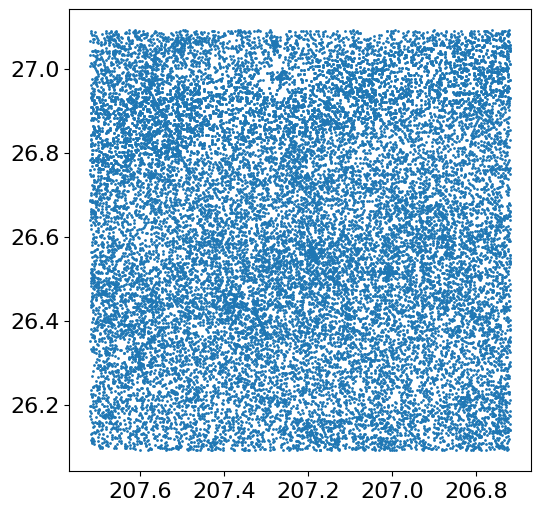

In [148]:
plt.figure(figsize=(6,6))
plt.scatter(SDSS['ra'],SDSS['dec'],s=1)

# we want to do these next two things any time we make an RA/Dec plot
# this sets the plot XY equal in coordinate degrees (but doesnt factor in the cos(dec) distortion)
plt.gca().set_aspect('equal')
# this inverts the ra axis so that east is to the left (ie usual astronomical orientation)
plt.gca().invert_xaxis()

### Do the same thing, but this time only for extended objects (ie galaxies)

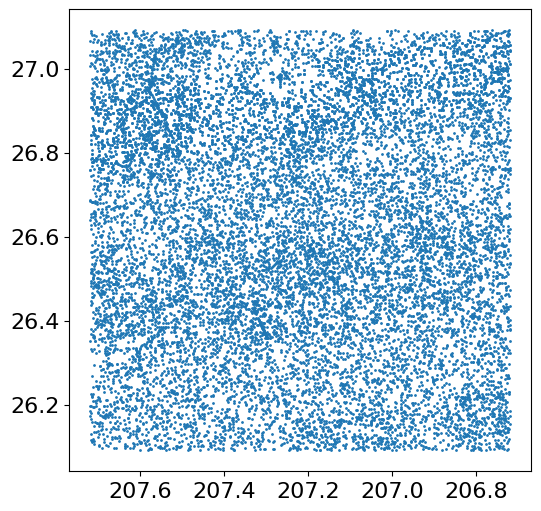

In [149]:
gals = SDSS['type']==3 # Extended objects are things with TYPE = 3.
plt.figure(figsize=(6,6))
plt.scatter(SDSS['ra'][gals],SDSS['dec'][gals],s=1)

plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()

### Well, that's a mess. How about doing it just for bright galaxies?

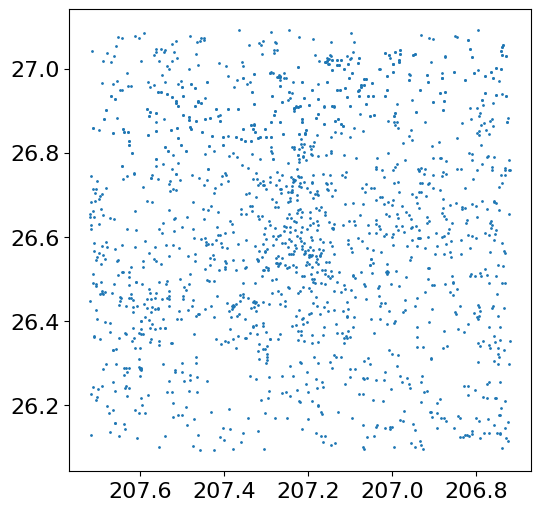

In [150]:
# let's call a galaxy 'bright' if it's brighter than a given r-magnitude
r_maglim = 20.0
brightgals = np.logical_and(gals,SDSS['r']<r_maglim)

plt.figure(figsize=(6,6))
plt.scatter(SDSS['ra'][brightgals],SDSS['dec'][brightgals],s=1)

plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()

### Redo that, overlaying with red X's the ones that have redshifts

Number of bright galaxies = 1780
Number of those that have redshifts = 251


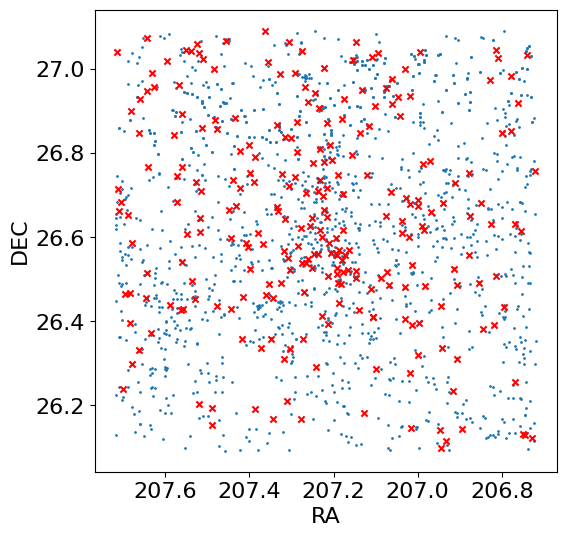

In [151]:
plt.figure(figsize=(6,6))
plt.scatter(SDSS['ra'][brightgals],SDSS['dec'][brightgals],s=1)

# remember that if an object doesn't have a measured redshift, we had set its redshift to -999
brightgals_withz = np.logical_and(brightgals,SDSS['redshift']>0)
plt.scatter(SDSS['ra'][brightgals_withz],SDSS['dec'][brightgals_withz],s=20,marker='x',color='red')

plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()

plt.xlabel('RA')
plt.ylabel('DEC')

print('Number of bright galaxies = {}'.format(np.sum(brightgals)))
print('Number of those that have redshifts = {}'.format(np.sum(brightgals_withz)))


### Let's examine the structural fits, whether a galaxy is better fit by an exponential model or a deVaucouleur model.

Text(20, -3500, 'Elliptical-like')

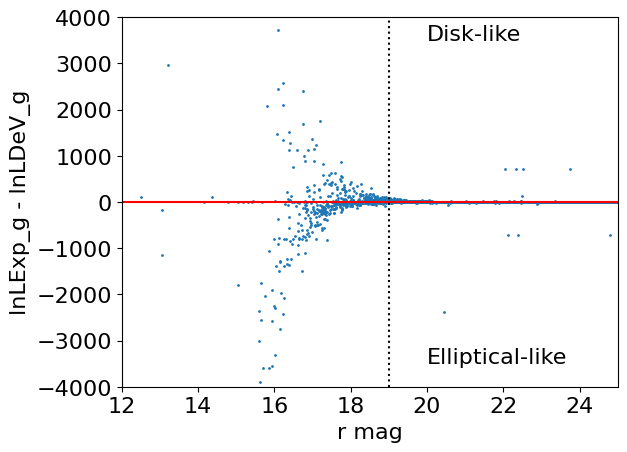

In [152]:
# just select resolved objects within 30 arcmin of the cluster center
resolved_inside30 = np.logical_and(SDSS['type']==3,SDSS['angdist_arcsec']<1800)

# lnLExp_g is the log-likelihood that the object is well fit by an exponential disk model
# lnLDeV_g is the log-likelihood that the object is well fit by a deVaucouleur elliptical galaxy model
#  so if lnLExp_g > lnLDeV_g, the object is more likely to be a disk galaxy
# and if lnLExp_g < lnLDeV_g, the object is more likely to be an elliptical
# but remember, this doesn't mean it *is* a disk or an elliptical!

plt.scatter(SDSS['r'][resolved_inside30],SDSS['lnLExp_g'][resolved_inside30]-SDSS['lnLDeV_g'][resolved_inside30],s=1)
plt.xlim(12,25)
plt.ylim(-4000,4000)

plt.axhline(y=0,color='red')
plt.axvline(x=19,color='black',ls=':')
plt.xlabel('r mag')
plt.ylabel('lnLExp_g - lnLDeV_g')
plt.text(20,3500,'Disk-like')
plt.text(20,-3500,'Elliptical-like')


### Look at an interactive table of galaxies (type=3) projected inside 10 arcminutes (10*60 = 600 arcsec)

In [153]:
"""
want = np.logical_and(SDSS['type']==3,SDSS['angdist_arcsec']< 600)
# uncomment one of these two:
SDSS[want].show_in_notebook(jsviewer = True) # to show it in the jupyter notebook
#SDSS[want].show_in_browser(jsviewer=True) # to show it in a browser page

# Note, I do not recommend doing this for the full dataset, it's too big!
"""

"\nwant = np.logical_and(SDSS['type']==3,SDSS['angdist_arcsec']< 600)\n# uncomment one of these two:\nSDSS[want].show_in_notebook(jsviewer = True) # to show it in the jupyter notebook\n#SDSS[want].show_in_browser(jsviewer=True) # to show it in a browser page\n\n# Note, I do not recommend doing this for the full dataset, it's too big!\n"

### Plot redshift versus r-band magnitude for galaxies that have a measured redshift and are within 30 arcminutes of the cluster center. Using the plot as a guide, work out a quantitative, statistical estimate of the cluster redshift. If you wanted to define a "spectroscopically confirmed cluster member", how might you do it?

Tip: Look at the redshift plot, decide what range of redshifts define the cluster. It'll help to set your ylimits to show a redshift range of z=0-0.1, where the cluster should be. 

Then make a selection on galaxies with redshifts in that range, and calculate the average redshift of just those objects.

Then make a new flag to indicate "spectroscopically confirmed galaxies".

0.06301544658064516


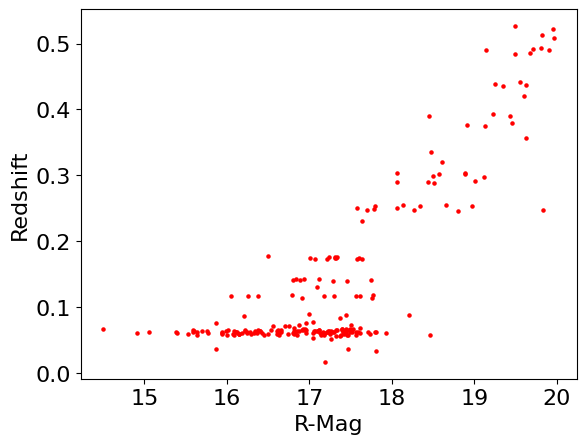

In [154]:
# your code to plot and work out redshift info goes here


plt.scatter(SDSS['r'][brightgals_withz & resolved_inside30],SDSS['redshift'][brightgals_withz & resolved_inside30],s=5,color='red')


plt.xlabel("R-Mag")
plt.ylabel("Redshift")


redshift_u1 = SDSS['redshift']<0.1
spec_con_gal = np.logical_and(SDSS['redshift']<0.1, brightgals_withz, resolved_inside30)

cluster_redshift = np.average(SDSS['redshift'][spec_con_gal])
print(cluster_redshift)

# when this block is finished, you should have created a variable called
# 'cluster_redshift' which has calculated your estimate of the cluster's redshift

### Now that we know the redshift of the cluster, let's work out how the angular size of a 1 Mpc radius, and plot things inside/outside that radius.

At z=0.0630, 1 Mpc projects to 797.1 arcsec


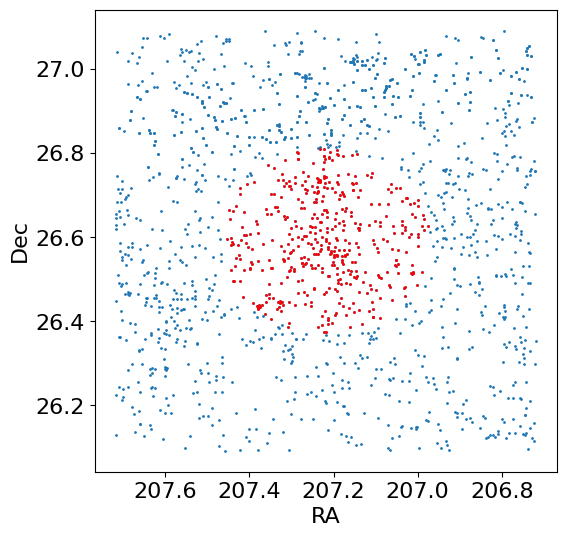

In [155]:
# import the astropy cosmology package, setting the cosmology to the Planck18 result
from astropy.cosmology import Planck18 as cosmo

# calculate the angular size distance to the cluster
DA = cosmo.angular_diameter_distance(cluster_redshift) # this is the angular diameter distance in Mpc

# and now we can work out the angular size that corresponds to a cluster radius of 1 Mpc
# Here we are just ysing the small angle approximation: 
#    angle[radians] = physical size / distance
# (and remember physical size and distance must be in the same units!)
# Then we convert from radians to arcseconds by multiplying by 206265
One_Mpc_In_Arcsec = (1.0/DA.value) * 206265
print('At z={:.4f}, 1 Mpc projects to {:.1f} arcsec'.format(cluster_redshift,One_Mpc_In_Arcsec))

# now make a flag that indicates if a galaxy is inside 1 Mpc or not:
inside1Mpc = SDSS['angdist_arcsec']<One_Mpc_In_Arcsec

# while we are playing with astropy.cosmology, let's get the luminosity distance to the
# cluster and work out the distance modulus to convert apparent magnitude to absolute
# magnitude, in case we need it later:
DL = cosmo.luminosity_distance(cluster_redshift) # this is the luminosity distance in Mpc
distmod = 5.*np.log10(DL.value*1e6) - 5
# so if we ever need an r-band absolute magnitude we can calculate it as r_absmag = SDSS['r'] - distmod

# for more details on cosmological distance definitions, go to my ASTR222 website:
#    http://burro.case.edu/Academics/Astr222/Cosmo/Observing/observing.shtml


#OK, let's plot things

plt.figure(figsize=(6,6))

# first plot all bright galaxies
plt.scatter(SDSS['ra'][brightgals],SDSS['dec'][brightgals],s=1)

# now select all galaxies which are bright AND inside 1 Mpc
want = np.logical_and(brightgals,inside1Mpc)
plt.scatter(SDSS['ra'][want],SDSS['dec'][want],s=1,color='red')

plt.xlabel("RA")
plt.ylabel("Dec")

plt.gca().set_aspect('equal')
plt.gca().invert_xaxis()

### Plot g-r color versus r magnitude for all resolved sources projected within 1 Mpc of the cluster center -- this is a color-magnitude diagram (CMD) for galaxies.

*Tip: Remember to use appropriate ranges: a reasonable r-mag range is r = 13 to 24 and a reasonable g-r color range is g-r = -1 to +2.*

Text(0.5, 0, 'r magnitude')

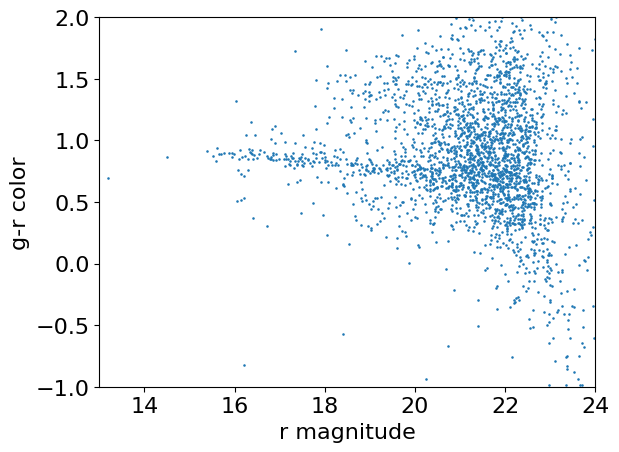

In [156]:
g_r_color = SDSS['g'] - SDSS['r']

all_gal_1MPC = np.logical_and(SDSS['type']==3,inside1Mpc)

plt.scatter(SDSS['r'][all_gal_1MPC], g_r_color[all_gal_1MPC], s = .7)
plt.xlim(13,24)
plt.ylim(-1,2)

plt.ylabel("g-r color")
plt.xlabel("r magnitude")

### Plot the CMD again, then overplot in a different color the CMD for spectroscopically confirmed cluster members. Again, restrict it to resolved sources projected within 1 Mpc of the center.

*Tip: Do a dual selection: galaxies within the 1 Mpc projected radius AND within the range of redshifts that you defined for the cluster. Then plot the CMD for those galaxies on top of the one you made in the previous step for all objects projected within 1 Mpc. Use a different color/symbol for the spectroscopically confirmed galaxies*

Text(0.5, 0, 'r magnitude')

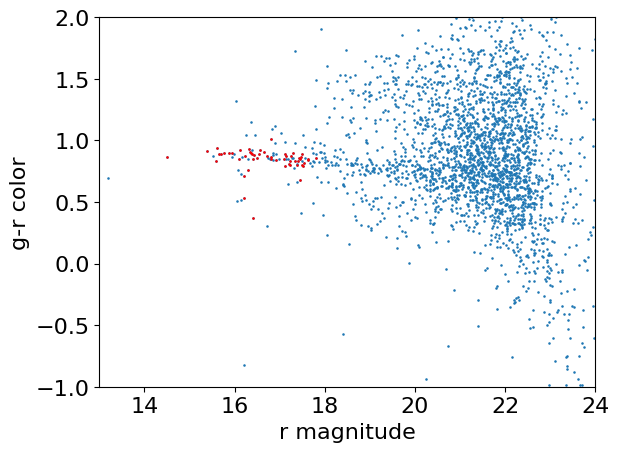

In [157]:
plt.scatter(SDSS['r'][all_gal_1MPC], g_r_color[all_gal_1MPC], s = .7)

z_low, z_high = 0.06,0.09
spec_confirmed = np.logical_and(SDSS['redshift']>z_low, SDSS['redshift'] < z_high) 
spectroscopic_cluster_members = np.logical_and(all_gal_1MPC, spec_confirmed)


plt.scatter(SDSS['r'][spectroscopic_cluster_members], g_r_color[spectroscopic_cluster_members], s = .7, color = 'red')
plt.xlim(13,24)
plt.ylim(-1,2)

plt.ylabel("g-r color")
plt.xlabel("r magnitude")

### Identify the bluest spectrosocopically confirmed galaxies, find their ra and dec, and then find them using Skyserver's "Navigate" function. What do they look like morphologically? Spectroscopically?

*Tip: Define a new column of data for the SDSS data table to hold the g-r color: SDSS['g-r']=SDSS['g']-SDSS['r']. The do a show_in_browser call on objects within the cluster redshift range. Sort on the g-r column to find the bluest objects and look at their coordinates. Then find them using Navigate.*

In [158]:
SDSS['g-r']=SDSS['g']-SDSS['r']
SDSS_spec_confirmed = SDSS[spectroscopic_cluster_members]
SDSS_spec_confirmed.sort('g-r')
SDSS_spec_confirmed.pprint_all()

       ra              dec        type    u        g        r        i        z     modelMagErr_u modelMagErr_g modelMagErr_r modelMagErr_i modelMagErr_z  lnLDeV_g  lnLExp_g  redshift  redshiftErr    angdist_arcsec          g-r        
---------------- ---------------- ---- -------- -------- -------- -------- -------- ------------- ------------- ------------- ------------- ------------- --------- --------- ---------- ------------ ------------------ ------------------
207.217489060027 26.6013640218775    3 20.76401  25.1144 24.80205 24.36182 16.74749     0.2197561      3.235922      3.866619      3.774065    0.02078172       0.0       0.0 0.06204706 2.992992e-05  35.42642903585221 0.3123499999999986
207.322428610266 26.7515730459682    3 17.86116 16.77474 16.40337 16.10388 16.03572     0.0229484    0.00555908   0.005398283   0.005188815    0.01371343 -1516.892 -246.8347 0.06464916 8.733204e-06  665.3336943887588 0.3713700000000024
207.067513506528 26.4870242311418    3 17.96364 16.75075

### Identify the most luminous spectroscopically confirmed galaxies and look at them in Navigator. What do they look like morphologically? Spectroscopically?

*Tip: Now sort your show_in_browser table on the r-magnitude and look at the coordinates of the brightest object. Then find it using Navigate.*


In [159]:
SDSS_spec_confirmed.sort('r')
SDSS_spec_confirmed.reverse()
SDSS_spec_confirmed[:5].pprint_all()

       ra              dec        type    u        g        r        i        z     modelMagErr_u modelMagErr_g modelMagErr_r modelMagErr_i modelMagErr_z  lnLDeV_g  lnLExp_g  redshift  redshiftErr    angdist_arcsec          g-r        
---------------- ---------------- ---- -------- -------- -------- -------- -------- ------------- ------------- ------------- ------------- ------------- --------- --------- ---------- ------------ ------------------ ------------------
207.217489060027 26.6013640218775    3 20.76401  25.1144 24.80205 24.36182 16.74749     0.2197561      3.235922      3.866619      3.774065    0.02078172       0.0       0.0 0.06204706 2.992992e-05  35.42642903585221 0.3123499999999986
207.226255621687  26.601554302035    3 20.60276  25.1144 17.93097 17.36593 16.83679    0.08348563      1.529368    0.00691356   0.006269234    0.01124455       0.0       0.0 0.06110387 2.107983e-05 43.022668877027186  7.183430000000001
207.215746609567 26.6476000394811    3 20.51975 18.65155

### Identify the highest redshift objects in the field (they won't be in the cluster, obviously!) and find them in Navigator. What do they look like, morphologically and spectroscopically?

*Tip: Don't worry if SDSS classifies it as a galaxy or not, or if it is inside 1 Mpc or not. Just do a show_in_browser call on all objects with a redshift (whether or not they are in the cluster redshift range), and sort on the redshift to find the coordinates of the highest redshift object.*

In [160]:
withz = SDSS['redshift']>0
SDSS_withz = SDSS[withz]
SDSS_withz.sort('z')
SDSS_withz.reverse()
SDSS_withz[:5].pprint_all()

       ra              dec        type    u        g        r        i        z     modelMagErr_u modelMagErr_g modelMagErr_r modelMagErr_i modelMagErr_z    lnLDeV_g      lnLExp_g     redshift   redshiftErr    angdist_arcsec            g-r         
---------------- ---------------- ---- -------- -------- -------- -------- -------- ------------- ------------- ------------- ------------- ------------- ------------- ------------- ------------ ------------ ------------------ ---------------------
 207.29078269809 26.9905828847853    3 24.66908 18.02214 17.25192 17.10047  22.8441       6.65643    0.01310411    0.01094058    0.01520597      5.778585     -76.49985     -172.3235   0.06109873 5.328868e-05 1454.8153580028243    0.7702200000000019
206.961420076884 26.9605705581564    6 22.23164 21.47597 21.77172 21.67167 22.45284      0.278594    0.05672972     0.1131346     0.1690722     0.9969776    -0.3885073    -0.3885048     2.338619  0.001098055 1564.9169770187298   -0.2957499999999982
207.

### Now make a CMD color-coded by disk vs elliptical likelihood, just for galaxies projected inside 1 Mpc of the cluster center.

*Tip: define a flag for disky things by saying **disky = SDSS['lnLExp_g'] > SDSS['lnLDeV_g']** and vice versa for E's. Then plot the CMD for disky things in blue and elliptical things in red.*

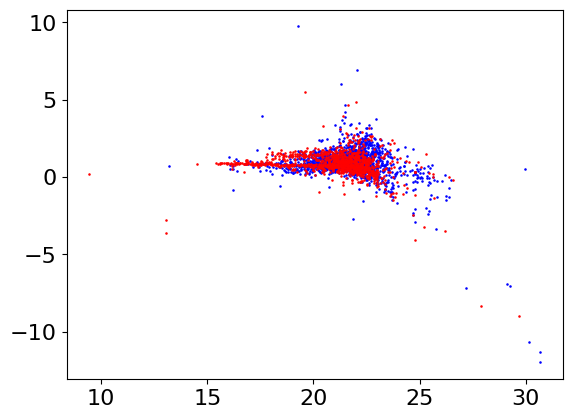

In [161]:
disky = SDSS['lnLExp_g'] > SDSS['lnLDeV_g']
elliptic = SDSS['lnLExp_g'] < SDSS['lnLDeV_g']



plt.scatter(SDSS['r'][np.logical_and(disky, all_gal_1MPC)],SDSS['g-r'][np.logical_and(disky, all_gal_1MPC)], color = 'blue', s= 0.7,)
plt.scatter(SDSS['r'][np.logical_and(elliptic, all_gal_1MPC)], SDSS['g-r'][np.logical_and(elliptic, all_gal_1MPC)], color = 'red', s= 0.7,)